In [1]:
!pip install GaugeRnR numpy

In [2]:
!pip install pypetb

In [3]:
from pypetb import RnR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec

from pypetb import RnR
from pypetb.RnR import _render_calibration_table, _TECHNICIAN_COLORS, _TECHNICIAN_MARKERS


def RnR_RunChart_fixed(self):
    Fig1 = plt.figure(figsize=(18, 12))
    Fig1.set_facecolor("white")
    gs = mpl.gridspec.GridSpec(int((self.p / 5) + 1), 5, wspace=0, hspace=0.1)
    Fig1.suptitle(
        "\nRUN CHART FOR MEASUREMENT SYSTEM OF {} BY {}, {}".format(
            self._RnRNumeric__dict_key["3"],
            self._RnRNumeric__dict_key["2"],
            self._RnRNumeric__dict_key["1"],
        ),
        fontsize=20,
    )

    lst_TT = list()
    lst_TT.append(Fig1.add_subplot(gs[0, :2]))
    lst_TT.append(Fig1.add_subplot(gs[0, 2]))
    lst_TT.append(Fig1.add_subplot(gs[0, 3:]))
    for i in range(1, len(lst_TT)):
        lst_TT[i].set_xticks([]); lst_TT[i].set_yticks([])
        lst_TT[i].set_facecolor("white")
        lst_TT[i].set_ylim(0, 1); lst_TT[i].set_xlim(0, 1)

    _render_calibration_table(
        lst_TT[0], self.Total_max, self.Total_avg, self.Total_min
    )
    lst_TT[1].annotate(
        "Panel var: {}".format(self._RnRNumeric__dict_key["2"]),
        xy=(0, 0.1), bbox=dict(boxstyle="round", fc="w"),
        fontsize=12, fontstyle="italic",
    )

    row, column = 1, 0
    lst_ax = list()

    df = self._RnRNumeric__df
    idx_ops = df.index.unique(level="OP")
    dict_OperatorLine = {
        idx_ops[i]: {
            "Color":  _TECHNICIAN_COLORS[i % len(_TECHNICIAN_COLORS)],
            "Marker": _TECHNICIAN_MARKERS[i % len(_TECHNICIAN_MARKERS)],
        }
        for i in range(len(idx_ops))
    }

    for counter in range(0, self.p):
        str_piece = df.index.unique(level="Part")[counter]
        df_temp = df.xs(str_piece, level=1, drop_level=False)
        lst_ax.append(Fig1.add_subplot(gs[row, column]))
        lst_ax[counter].set_title(str_piece, fontweight="bold")
        lst_ax[counter].yaxis.set_major_locator(plt.MaxNLocator(3))
        lst_ax[counter].set_yticks([])
        lst_ax[counter].set_xticks([])
        lst_ax[counter].set_ylim(self.Total_min, self.Total_max)
        column += 1
        if column > 4:
            row += 1
            column = 0

        t_base = 0
        for key in dict_OperatorLine:
            # ---- FIX: use self.r (number of runs) for the x-axis ----
            x = np.arange(t_base, t_base + len(range(0, self.r)))
            str_op = key
            y = df_temp.xs(str_op, level=0, drop_level=False).values.flatten()
            t_base = t_base + len(range(0, self.r))
            # ---------------------------------------------------------
            lst_ax[counter].plot(
                x, y,
                label=str_op,
                color=dict_OperatorLine[key]["Color"],
                marker=dict_OperatorLine[key]["Marker"],
            )
            lst_ax[counter].axhline(
                self.Total_avg, color="black", linestyle="--"
            )

    lst_ax[4].legend(
        loc="upper right",
        bbox_to_anchor=(0.6, 1.7),
        title="{}".format(self._RnRNumeric__dict_key["1"]),
    )
    return Fig1


# Replace the buggy method
RnR.RnRNumeric.RnR_RunChart = RnR_RunChart_fixed

## R y R convencional

In [5]:
# Load measurement dataset
url = 'https://raw.githubusercontent.com/jgherruzo/myFreeDatasets/main/RnR_Example.csv' # noqa
df=pd.read_csv(url,sep=';')
print(df.info()) # In order to check column names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Part         90 non-null     int64  
 1   Operator     90 non-null     object 
 2   Measurement  90 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB
None


In [6]:
#Build up the model
dict_key={
        '1':'Operator',
        '2':'Part',
        '3':'Measurement'
        }
RnRModel=RnR.RnRNumeric(
    mydf_Raw=df,
    mydict_key=dict_key,
    mydbl_tol=8
    )
#Solve it
RnRModel.RnRSolve()
#Check the calculation
print(RnRModel.getLog())

Model is created
== DATASET EVALUATION ==
Operator: 3
Trials: 3
Piezes: 10
== CALCULATION ==
Total data: 90
Max. measured value: 2.2600
Min. measured value: -2.1600
Avg. measured value: 0.0014
Avg. Control limits
UCL: 0.3510
LCL: -0.3481
Avg. Range measured: 0.3417
Range Control limits
UCL: 0.8794
LCL: 0.0000
Sum of deviation by operator: 0.105575
Total Operator Sum of deviation: 3.167262
Sum of deviation by part: 9.817993
Total Part Sum of deviation: 88.361934
Total squared deviation: 94.647112
Equipment squared deviation: 2.758933
Iteration sum of squared: 0.358982



In [7]:
df_Result=RnRModel.RnRAnova()
#Checking Anova table
print(df_Result)
#accesing one individual value
print(f"Degree of freedom for part: {df_Result['DF'].loc['Part']}")

                       DF         SS        MS           F             P
Source of variability                                                   
Technician              2   3.167262  1.583631   79.406049  1.174478e-09
Part                    9  88.361934  9.817993  492.291423  0.000000e+00
TechxPart (iteration)  18   0.358982  0.019943    0.433721  9.741064e-01
Repeatability with     60   2.758933  0.045982         NaN           NaN
Repeatability without  78   3.117916  0.039973         NaN  9.741064e-01
Total                  89  94.647112       NaN         NaN           NaN
Degree of freedom for part: 9


In [8]:
df_Result=RnRModel.RnR_varTable()
#Checking var. table
print(df_Result)
#accesing one individual value
print('\nRnR RESULT:\n-------------------')

dbl_RnR=df_Result['% Contribution'].loc['Total Gage R&R']
print(f"Total Gage R&R: {dbl_RnR:.3f}")
if dbl_RnR<1:
    print('<1% --> Acceptable measurement system')
elif dbl_RnR>=1 and dbl_RnR<=9:
    print(
        '1-9%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>9% --> Unacceptable measurement system, it must be improved'
        )

                           Variance  % Contribution
Source                                             
Total Gage R&R             0.091429        7.762159
Eq.Var. (Repeatability)    0.039973        3.393677
Op.Var. (Reproducibility)  0.051455        4.368482
Technician                 0.051455        4.368482
Technician x Part iter.    0.000000        0.000000
Part to Part               1.086447       92.237841
Total variation            1.177875      100.000000

RnR RESULT:
-------------------
Total Gage R&R: 7.762
1-9%--> It may be acceptable depending on application and cost


In [9]:
df_Result=RnRModel.RnR_SDTable()
#Checking sd table
print(df_Result)
#accesing one individual value
print('\nAutomotive Industry Action Group (AIAG) measurement system assessment:\n-------------------')

dbl_RnR=df_Result['% tol (VE/tol)'].loc['Total Gage R&R']
print(f"% tol (VE/tol): {dbl_RnR:.3f}")
if dbl_RnR<10:
    print('<10% --> Acceptable measurement system')
elif dbl_RnR>=10 and dbl_RnR<=30:
    print(
        '10-30%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>30% --> Unacceptable measurement system, it must be improved'
        )

                           StdDev (SD)  StudyVar (6*SD)  % Study Var  \
Source                                                                 
Total Gage R&R                0.302372         1.814229    27.860651   
Eq.Var. (Repeatability)       0.199933         1.199599    18.421935   
Op.Var. (Reproducibility)     0.226838         1.361025    20.900913   
Technician                    0.226838         1.361025    20.900913   
Technician x Part iter.       0.000000         0.000000     0.000000   
Part to Part                  1.042327         6.253965    96.040534   
Total variation               1.085300         6.511797   100.000000   

                           % tol (VE/tol)  
Source                                     
Total Gage R&R                  22.677864  
Eq.Var. (Repeatability)         14.994988  
Op.Var. (Reproducibility)       17.012814  
Technician                      17.012814  
Technician x Part iter.          0.000000  
Part to Part                    78.174562  

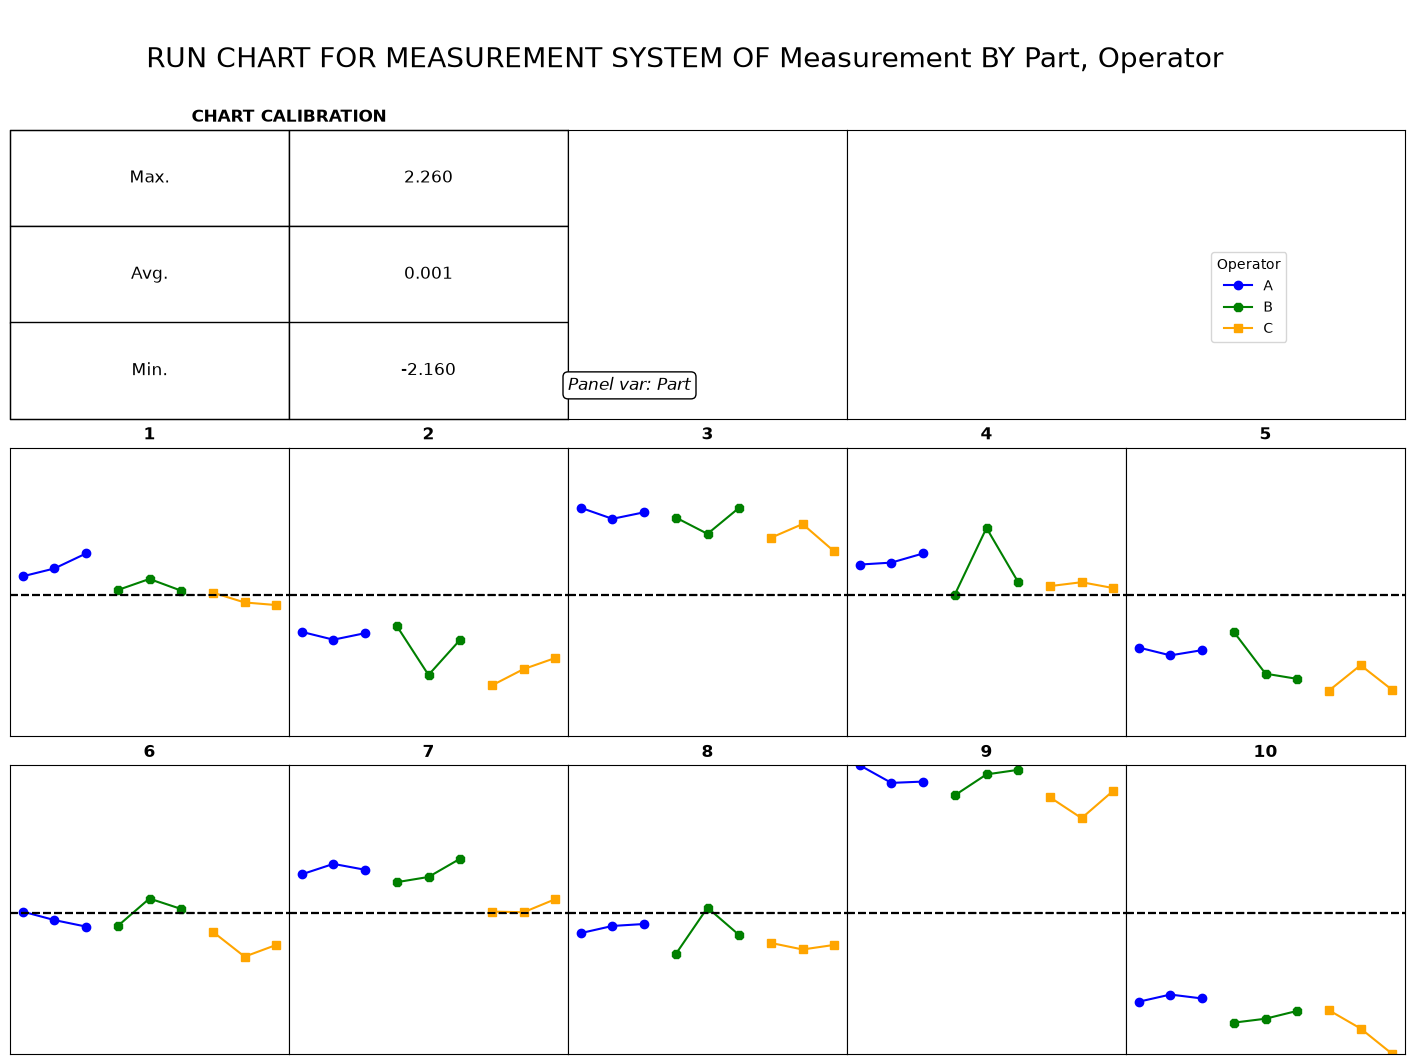

In [10]:
call=RnRModel.RnR_RunChart()
plt.show()

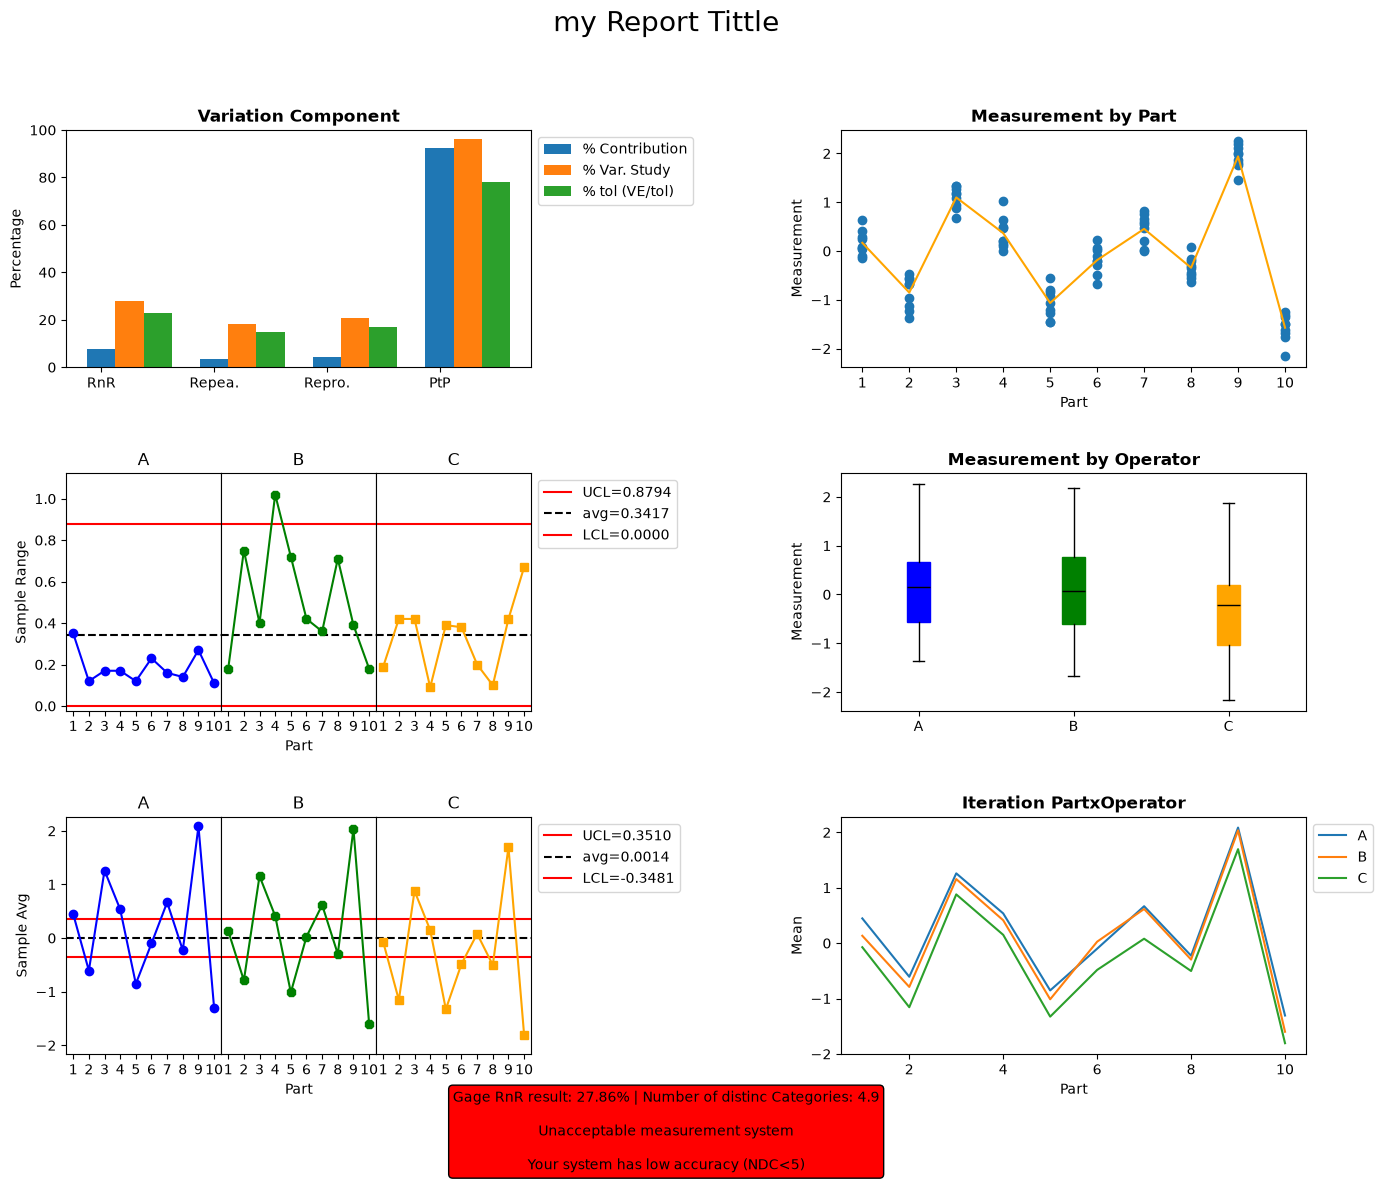

In [11]:
call=RnRModel.RnR_Report("my Report Tittle")
plt.show()

In [12]:
df

,Part,Operator,Measurement
0,1,A,0.29
1,1,A,0.41
2,1,A,0.64
3,2,A,-0.56
4,2,A,-0.68
...,...,...,...
85,9,C,1.45
86,9,C,1.87
87,10,C,-1.49
88,10,C,-1.77


In [13]:
df.describe()

,Part,Measurement
count,90.000000,90.000000
mean,5.500000,0.001444
std,2.888373,1.031237
min,1.000000,-2.160000
25%,3.000000,-0.677500
50%,5.500000,0.015000
75%,8.000000,0.640000
max,10.000000,2.260000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Part         90 non-null     int64  
 1   Operator     90 non-null     object 
 2   Measurement  90 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB


In [15]:
df.nunique()

Part           10
Operator        3
Measurement    77
dtype: int64

## Ejemplo 2

In [16]:
df = pd.read_csv('EjemploRyR1.txt', sep = "\t")
df

,Mediciones,Parte,Operario
0,1.141,1,A
1,1.144,2,A
2,1.146,3,A
3,1.139,4,A
4,1.143,5,A
...,...,...,...
130,1.146,11,C
131,1.136,12,C
132,1.143,13,C
133,1.142,14,C


In [17]:
#Build up the model
dict_key={
        '1':'Operario',
        '2':'Parte',
        '3':'Mediciones'
        }
RnRModel=RnR.RnRNumeric(
    mydf_Raw=df,
    mydict_key=dict_key,
    mydbl_tol=0.1
    )
#Solve it
RnRModel.RnRSolve()
#Check the calculation
print(RnRModel.getLog())


Model is created
== DATASET EVALUATION ==
Operator: 3
Trials: 3
Piezes: 15
== CALCULATION ==
Total data: 135
Max. measured value: 1.1530
Min. measured value: 1.1350
Avg. measured value: 1.1425
Avg. Control limits
UCL: 1.1449
LCL: 1.1401
Avg. Range measured: 0.0024
Range Control limits
UCL: 0.0061
LCL: 0.0000
Sum of deviation by operator: 0.000013
Total Operator Sum of deviation: 0.000574
Sum of deviation by part: 0.000139
Total Part Sum of deviation: 0.001249
Total squared deviation: 0.002148
Equipment squared deviation: 0.000266
Iteration sum of squared: 0.000059



In [18]:
df_Result=RnRModel.RnRAnova()
#Checking Anova table
print(df_Result)
#accesing one individual value
print(f"Degree of freedom for part: {df_Result['DF'].loc['Part']}")

                        DF        SS        MS           F             P
Source of variability                                                   
Technician               2  0.000574  0.000287  135.370629  3.996803e-15
Part                    14  0.001249  0.000089   42.103896  4.662937e-15
TechxPart (iteration)   28  0.000059  0.000002    0.716792  8.405460e-01
Repeatability with      90  0.000266  0.000003         NaN           NaN
Repeatability without  118  0.000325  0.000003         NaN  8.405460e-01
Total                  134  0.002148       NaN         NaN           NaN
Degree of freedom for part: 14


In [19]:
df_Result=RnRModel.RnR_varTable()
#Checking var. table
print(df_Result)
#accesing one individual value
print('\nRnR RESULT:\n-------------------')

dbl_RnR=df_Result['% Contribution'].loc['Total Gage R&R']
print(f"Total Gage R&R: {dbl_RnR:.3f}")
if dbl_RnR<1:
    print('<1% --> Acceptable measurement system')
elif dbl_RnR>=1 and dbl_RnR<=9:
    print(
        '1-9%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>9% --> Unacceptable measurement system, it must be improved'
        )

                           Variance  % Contribution
Source                                             
Total Gage R&R             0.000009       48.565127
Eq.Var. (Repeatability)    0.000003       14.764116
Op.Var. (Reproducibility)  0.000006       33.801011
Technician                 0.000006       33.801011
Technician x Part iter.    0.000000        0.000000
Part to Part               0.000010       51.434873
Total variation            0.000019      100.000000

RnR RESULT:
-------------------
Total Gage R&R: 48.565
>9% --> Unacceptable measurement system, it must be improved


In [20]:
df_Result=RnRModel.RnR_SDTable()
#Checking sd table
print(df_Result)
#accesing one individual value
print('\nAutomotive Industry Action Group (AIAG) measurement system assessment:\n-------------------')

dbl_RnR=df_Result['% tol (VE/tol)'].loc['Total Gage R&R']
print(f"% tol (VE/tol): {dbl_RnR:.3f}")
if dbl_RnR<10:
    print('<10% --> Acceptable measurement system')
elif dbl_RnR>=10 and dbl_RnR<=30:
    print(
        '10-30%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>30% --> Unacceptable measurement system, it must be improved'
        )

                           StdDev (SD)  StudyVar (6*SD)  % Study Var  \
Source                                                                 
Total Gage R&R                0.003011         0.018069    69.688684   
Eq.Var. (Repeatability)       0.001660         0.009962    38.424102   
Op.Var. (Reproducibility)     0.002512         0.015074    58.138637   
Technician                    0.002512         0.015074    58.138637   
Technician x Part iter.       0.000000         0.000000     0.000000   
Part to Part                  0.003099         0.018595    71.718110   
Total variation               0.004321         0.025928   100.000000   

                           % tol (VE/tol)  
Source                                     
Total Gage R&R                  18.068545  
Eq.Var. (Repeatability)          9.962415  
Op.Var. (Reproducibility)       15.073905  
Technician                      15.073905  
Technician x Part iter.          0.000000  
Part to Part                    18.594725  

In [21]:
0.003011/0.004321

0.6968294376301781

In [22]:
(0.003011/0.004321)**2

0.4855712651479903

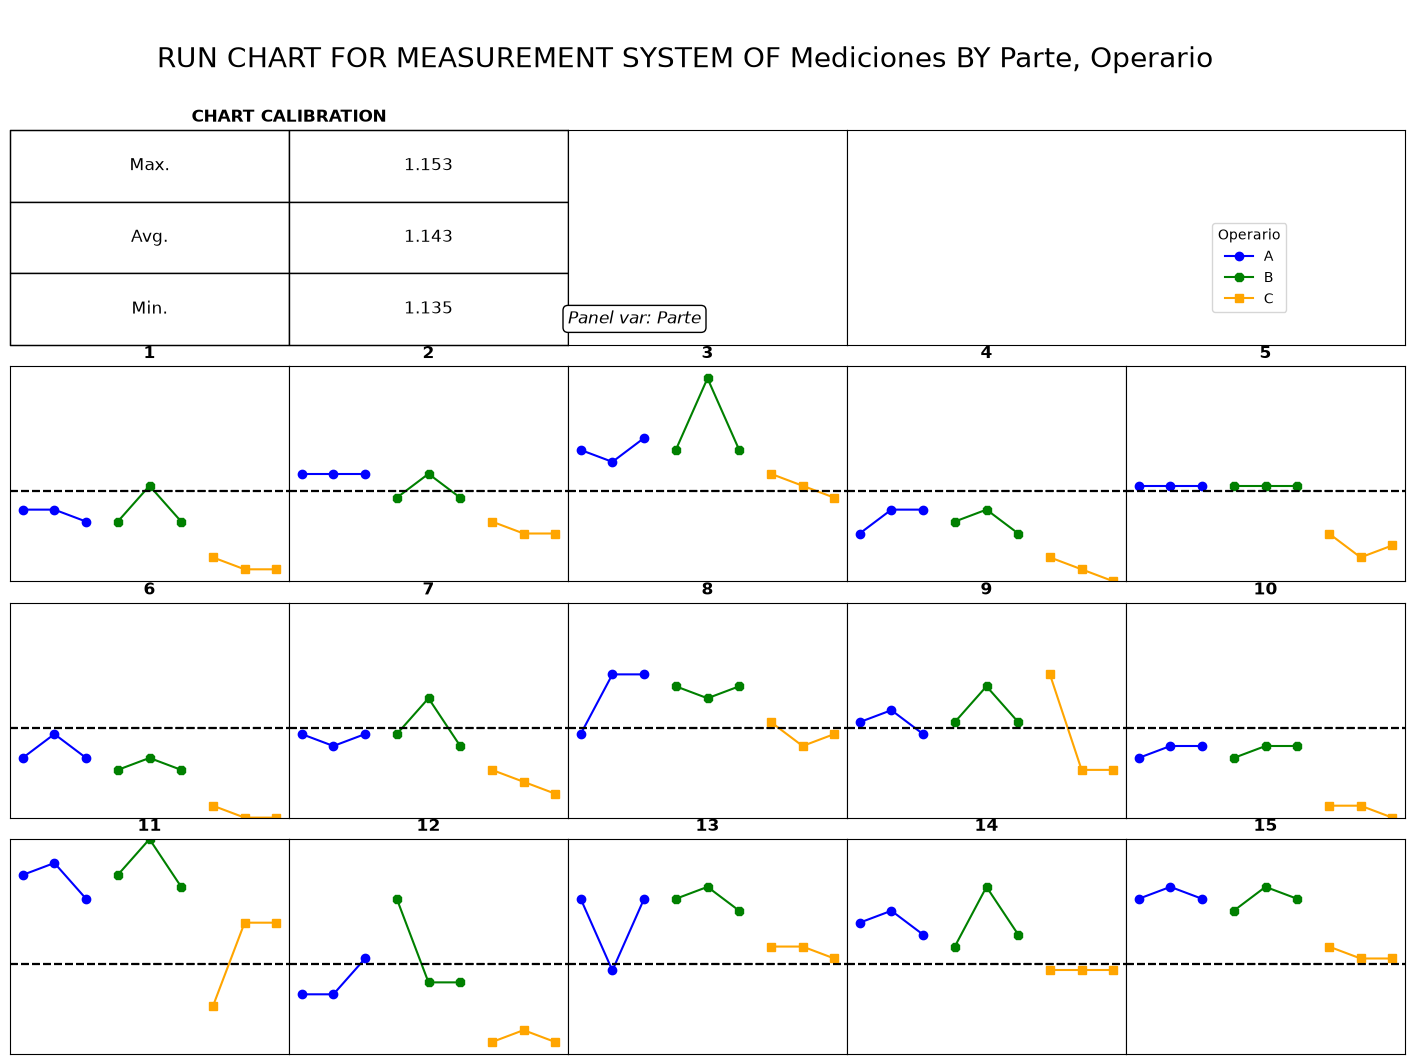

In [23]:
call=RnRModel.RnR_RunChart()
plt.show()

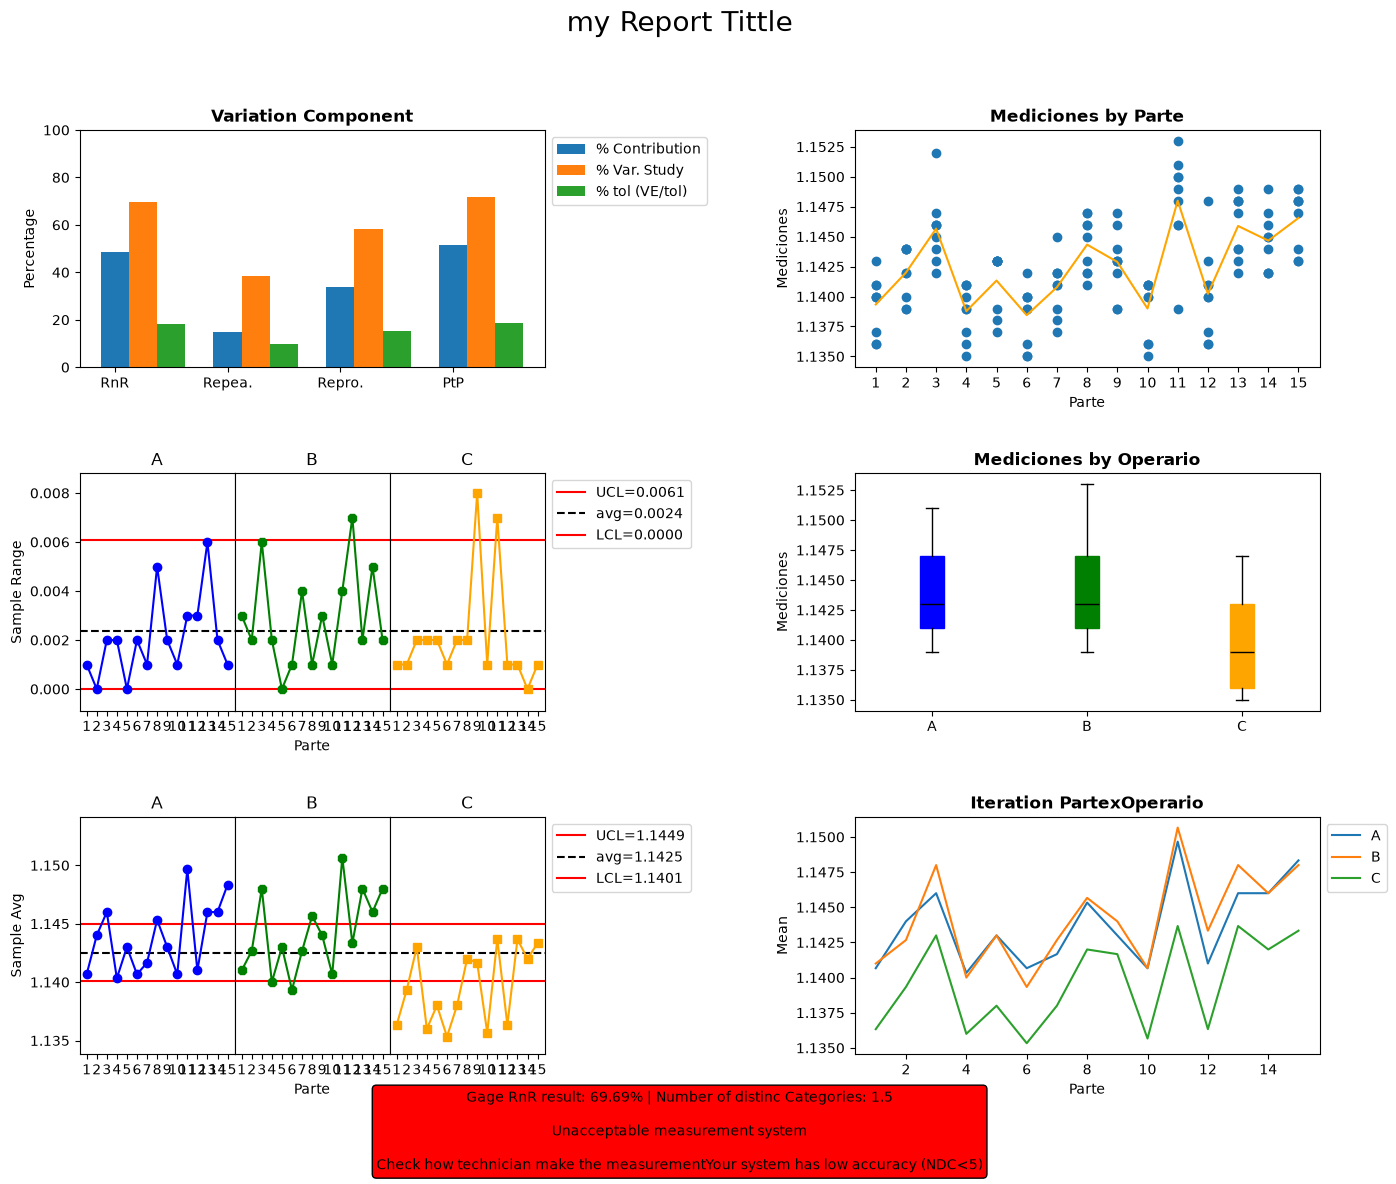

In [24]:
call=RnRModel.RnR_Report("my Report Tittle")
plt.show()

## Ejemplo 3

In [141]:
df = pd.read_csv('Datos1.txt', sep= '\t')
df

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


In [142]:
df = pd.read_excel('Datos1.xlsx')

In [143]:
df

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


In [144]:
df = pd.DataFrame(df)
df

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


In [145]:
df = pd.read_csv('Datos1.csv', sep= ';', decimal=',')
df

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Operario  60 non-null     object 
 1   Partes    60 non-null     int64  
 2   Ensayos   60 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ KB


In [147]:
print(df['Operario'].value_counts())

Operario
A    20
B    20
C    20
Name: count, dtype: int64


In [148]:
print(df['Ensayos'].value_counts().sum())

60


In [149]:
print(df['Partes'].value_counts())

Partes
1     6
2     6
3     6
4     6
5     6
6     6
7     6
8     6
9     6
10    6
Name: count, dtype: int64


In [150]:
print(df.isna().sum())

Operario    0
Partes      0
Ensayos     0
dtype: int64


In [151]:
print(df['Operario'].unique())

['A' 'B' 'C']


In [152]:
df.head(10)

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


In [153]:
df.columns

Index(['Operario', 'Partes', 'Ensayos'], dtype='object')

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Operario  60 non-null     object 
 1   Partes    60 non-null     int64  
 2   Ensayos   60 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ KB


In [155]:
!pip install pypetb

In [156]:
#Build up the model
dict_key={
        
        '1':'Operario',
        '2':'Partes',
        '3':'Ensayos'
        }
RnRModel=RnR.RnRNumeric(
    mydf_Raw=df,
    mydict_key=dict_key,
    mydbl_tol=15
    )
#Solve it
RnRModel.RnRSolve()
#Check the calculation
print(RnRModel.getLog())

Model is created
== DATASET EVALUATION ==
Operator: 3
Trials: 2
Piezes: 10
== CALCULATION ==
Total data: 60
Max. measured value: 37.1000
Min. measured value: 28.3000
Avg. measured value: 32.5033
Avg. Control limits
UCL: 33.8820
LCL: 31.1247
Avg. Range measured: 0.7333
Range Control limits
UCL: 2.3951
LCL: 0.0000
Sum of deviation by operator: 0.214717
Total Operator Sum of deviation: 4.294333
Sum of deviation by part: 62.381000
Total Part Sum of deviation: 374.286000
Total squared deviation: 393.659333
Equipment squared deviation: 12.050000
Iteration sum of squared: 3.029000



In [157]:
df_Result=RnRModel.RnRAnova()
#Checking Anova table
print(df_Result)
#accesing one individual value
print(f"Degree of freedom for part: {df_Result['DF'].loc['Part']}")

                       DF          SS         MS           F             P
Source of variability                                                     
Technician              2    4.294333   2.147167   12.759657  3.542536e-04
Part                    9  374.286000  41.587333  247.135028  1.110223e-16
TechxPart (iteration)  18    3.029000   0.168278    0.418949  9.719257e-01
Repeatability with     30   12.050000   0.401667         NaN           NaN
Repeatability without  48   15.079000   0.314146         NaN  9.719257e-01
Total                  59  393.659333        NaN         NaN           NaN
Degree of freedom for part: 9


In [158]:
df_Result=RnRModel.RnR_varTable()
#Checking var. table
print(df_Result)
#accesing one individual value
print('\nRnR RESULT:\n-------------------')

dbl_RnR=df_Result['% Contribution'].loc['Total Gage R&R']
print(f"Total Gage R&R: {dbl_RnR:.3f}")
if dbl_RnR<1:
    print('<1% --> Acceptable measurement system')
elif dbl_RnR>=1 and dbl_RnR<=9:
    print(
        '1-9%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>9% --> Unacceptable measurement system, it must be improved'
        )

                           Variance  % Contribution
Source                                             
Total Gage R&R             0.405797        5.570566
Eq.Var. (Repeatability)    0.314146        4.312429
Op.Var. (Reproducibility)  0.091651        1.258137
Technician                 0.091651        1.258137
Technician x Part iter.    0.000000        0.000000
Part to Part               6.878865       94.429434
Total variation            7.284661      100.000000

RnR RESULT:
-------------------
Total Gage R&R: 5.571
1-9%--> It may be acceptable depending on application and cost


In [159]:
df_Result=RnRModel.RnR_SDTable()
#Checking sd table
print(df_Result)
#accesing one individual value
print('\nAutomotive Industry Action Group (AIAG) measurement system assessment:\n-------------------')

dbl_RnR=df_Result['% tol (VE/tol)'].loc['Total Gage R&R']
print(f"% tol (VE/tol): {dbl_RnR:.3f}")
if dbl_RnR<10:
    print('<10% --> Acceptable measurement system')
elif dbl_RnR>=10 and dbl_RnR<=30:
    print(
        '10-30%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>30% --> Unacceptable measurement system, it must be improved'
        )

                           StdDev (SD)  StudyVar (6*SD)  % Study Var  \
Source                                                                 
Total Gage R&R                0.637022         3.822131    23.602047   
Eq.Var. (Repeatability)       0.560487         3.362923    20.766388   
Op.Var. (Reproducibility)     0.302739         1.816435    11.216672   
Technician                    0.302739         1.816435    11.216672   
Technician x Part iter.       0.000000         0.000000     0.000000   
Part to Part                  2.622759        15.736554    97.174808   
Total variation               2.699011        16.194067   100.000000   

                           % tol (VE/tol)  
Source                                     
Total Gage R&R                  25.480875  
Eq.Var. (Repeatability)         22.419486  
Op.Var. (Reproducibility)       12.109569  
Technician                      12.109569  
Technician x Part iter.          0.000000  
Part to Part                   104.910359  

In [160]:
RnRModel.t

3

In [161]:
RnRModel.p

10

In [162]:
RnRModel.r

2

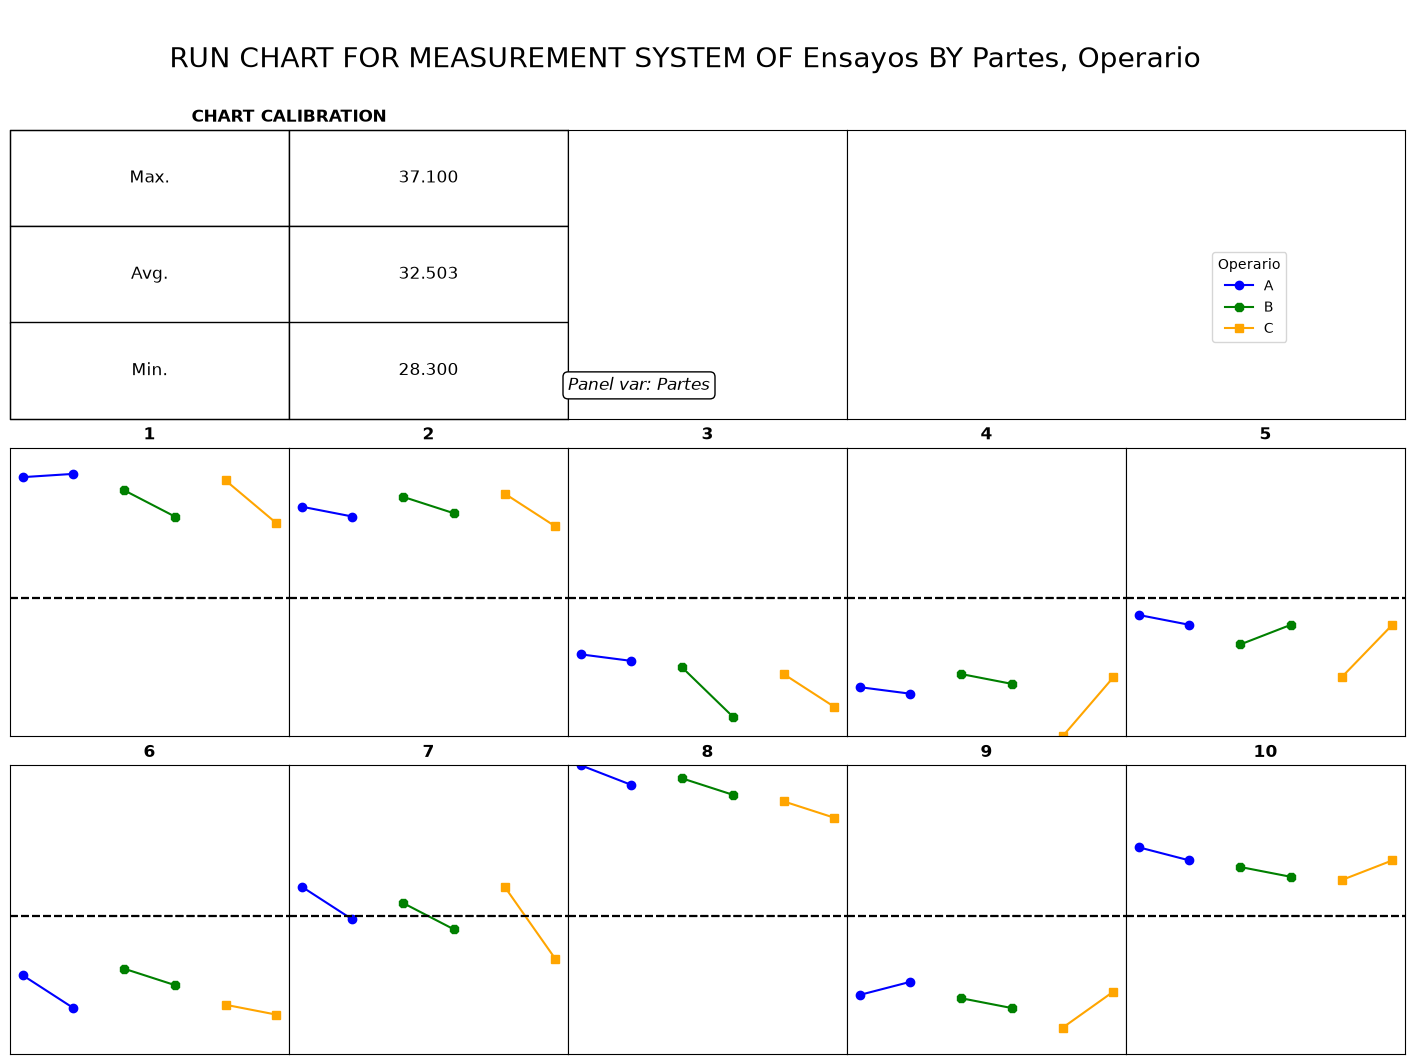

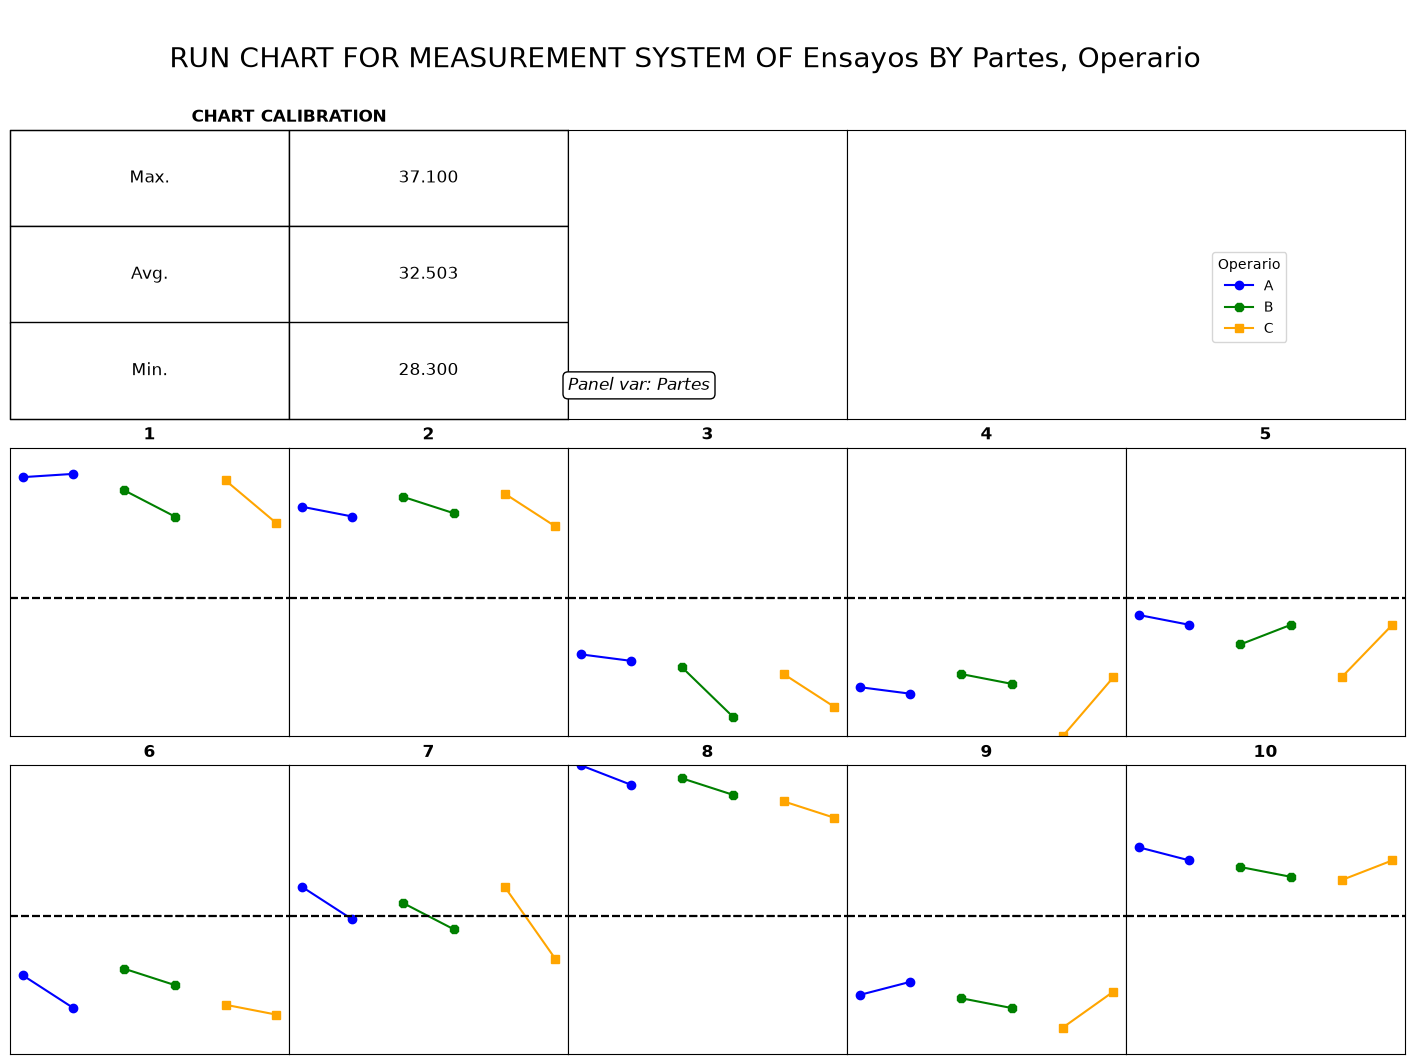

In [163]:
RnRModel.RnR_RunChart()

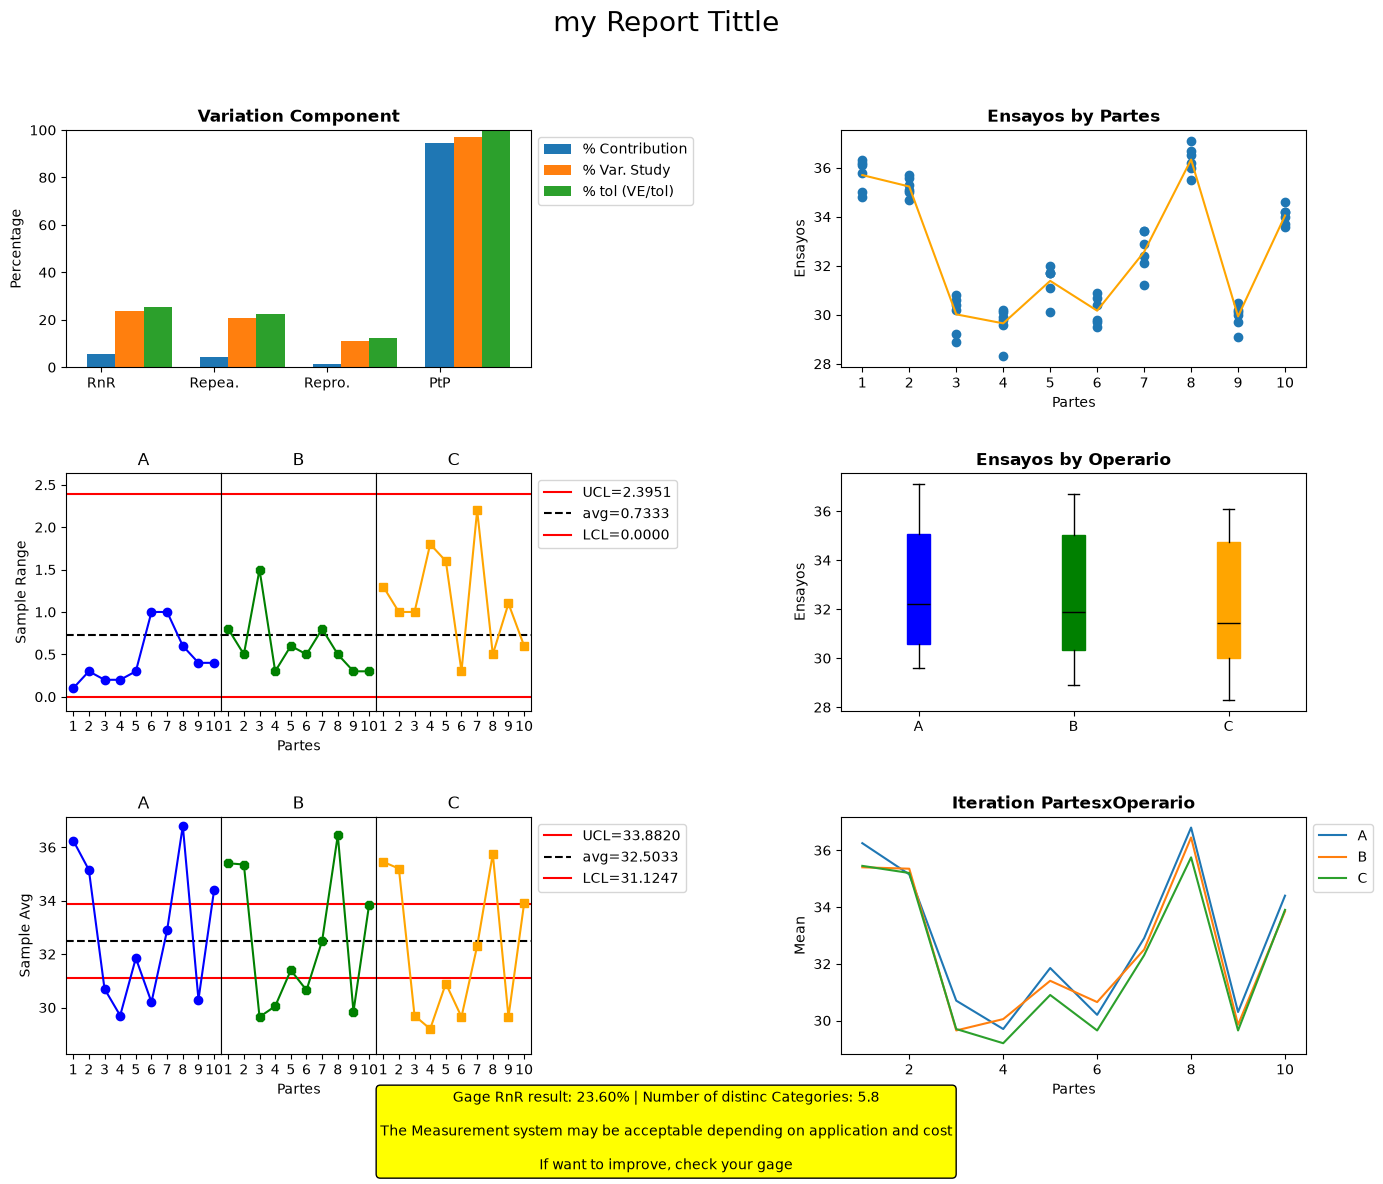

In [164]:
call=RnRModel.RnR_Report("my Report Tittle")
plt.show()

In [165]:
df

,Operario,Partes,Ensayos
0,A,1,36.2
1,A,2,35.3
2,A,3,30.8
3,A,4,29.8
4,A,5,32.0
5,A,6,30.7
6,A,7,33.4
7,A,8,37.1
8,A,9,30.1
9,A,10,34.6


## Ejemplo 4

In [166]:
df = pd.read_csv('EjemploRyR1.txt', sep= '\t')
df

,Mediciones,Parte,Operario
0,1.141,1,A
1,1.144,2,A
2,1.146,3,A
3,1.139,4,A
4,1.143,5,A
...,...,...,...
130,1.146,11,C
131,1.136,12,C
132,1.143,13,C
133,1.142,14,C


In [168]:
#Build up the model
dict_key={
        
        '1':'Operario',
        '2':'Parte',
        '3':'Mediciones'
        }
RnRModel=RnR.RnRNumeric(
    mydf_Raw=df,
    mydict_key=dict_key,
    mydbl_tol=15
    )
#Solve it
RnRModel.RnRSolve()
#Check the calculation
print(RnRModel.getLog())

Model is created
== DATASET EVALUATION ==
Operator: 3
Trials: 3
Piezes: 15
== CALCULATION ==
Total data: 135
Max. measured value: 1.1530
Min. measured value: 1.1350
Avg. measured value: 1.1425
Avg. Control limits
UCL: 1.1449
LCL: 1.1401
Avg. Range measured: 0.0024
Range Control limits
UCL: 0.0061
LCL: 0.0000
Sum of deviation by operator: 0.000013
Total Operator Sum of deviation: 0.000574
Sum of deviation by part: 0.000139
Total Part Sum of deviation: 0.001249
Total squared deviation: 0.002148
Equipment squared deviation: 0.000266
Iteration sum of squared: 0.000059



In [169]:
df_Result=RnRModel.RnRAnova()
#Checking Anova table
print(df_Result)
#accesing one individual value
print(f"Degree of freedom for part: {df_Result['DF'].loc['Part']}")

                        DF        SS        MS           F             P
Source of variability                                                   
Technician               2  0.000574  0.000287  135.370629  3.996803e-15
Part                    14  0.001249  0.000089   42.103896  4.662937e-15
TechxPart (iteration)   28  0.000059  0.000002    0.716792  8.405460e-01
Repeatability with      90  0.000266  0.000003         NaN           NaN
Repeatability without  118  0.000325  0.000003         NaN  8.405460e-01
Total                  134  0.002148       NaN         NaN           NaN
Degree of freedom for part: 14


In [170]:
df_Result=RnRModel.RnR_varTable()
#Checking var. table
print(df_Result)
#accesing one individual value
print('\nRnR RESULT:\n-------------------')

dbl_RnR=df_Result['% Contribution'].loc['Total Gage R&R']
print(f"Total Gage R&R: {dbl_RnR:.3f}")
if dbl_RnR<1:
    print('<1% --> Acceptable measurement system')
elif dbl_RnR>=1 and dbl_RnR<=9:
    print(
        '1-9%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>9% --> Unacceptable measurement system, it must be improved'
        )

                           Variance  % Contribution
Source                                             
Total Gage R&R             0.000009       48.565127
Eq.Var. (Repeatability)    0.000003       14.764116
Op.Var. (Reproducibility)  0.000006       33.801011
Technician                 0.000006       33.801011
Technician x Part iter.    0.000000        0.000000
Part to Part               0.000010       51.434873
Total variation            0.000019      100.000000

RnR RESULT:
-------------------
Total Gage R&R: 48.565
>9% --> Unacceptable measurement system, it must be improved


In [171]:
df_Result=RnRModel.RnR_SDTable()
#Checking sd table
print(df_Result)
#accesing one individual value
print('\nAutomotive Industry Action Group (AIAG) measurement system assessment:\n-------------------')

dbl_RnR=df_Result['% tol (VE/tol)'].loc['Total Gage R&R']
print(f"% tol (VE/tol): {dbl_RnR:.3f}")
if dbl_RnR<10:
    print('<10% --> Acceptable measurement system')
elif dbl_RnR>=10 and dbl_RnR<=30:
    print(
        '10-30%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>30% --> Unacceptable measurement system, it must be improved'
        )

                           StdDev (SD)  StudyVar (6*SD)  % Study Var  \
Source                                                                 
Total Gage R&R                0.003011         0.018069    69.688684   
Eq.Var. (Repeatability)       0.001660         0.009962    38.424102   
Op.Var. (Reproducibility)     0.002512         0.015074    58.138637   
Technician                    0.002512         0.015074    58.138637   
Technician x Part iter.       0.000000         0.000000     0.000000   
Part to Part                  0.003099         0.018595    71.718110   
Total variation               0.004321         0.025928   100.000000   

                           % tol (VE/tol)  
Source                                     
Total Gage R&R                   0.120457  
Eq.Var. (Repeatability)          0.066416  
Op.Var. (Reproducibility)        0.100493  
Technician                       0.100493  
Technician x Part iter.          0.000000  
Part to Part                     0.123965  

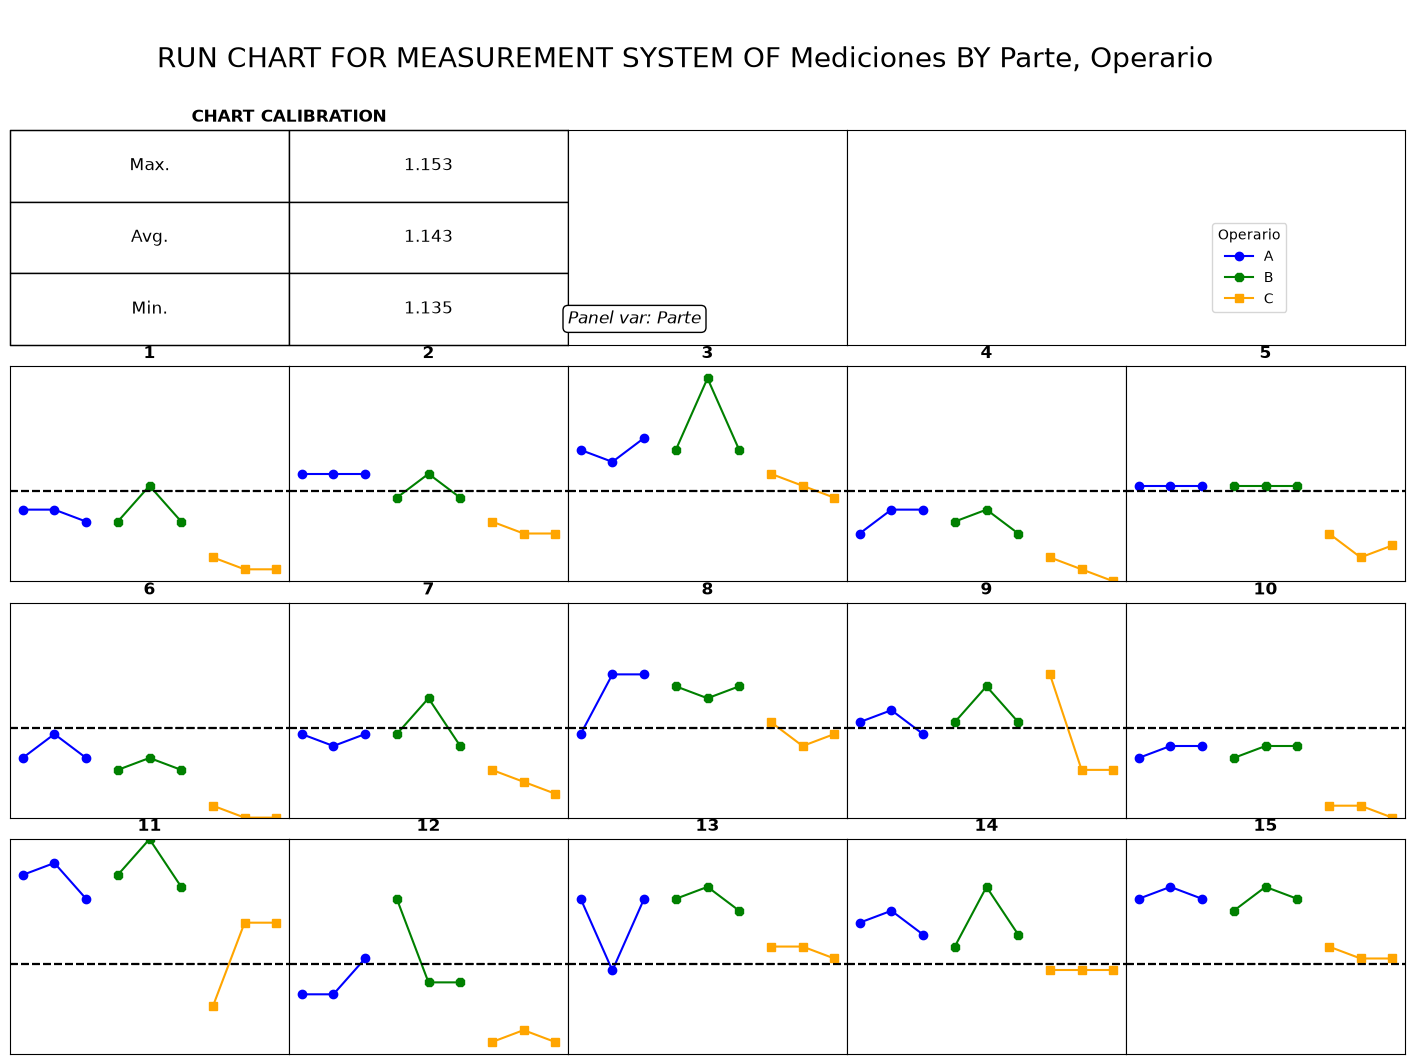

In [172]:
call=RnRModel.RnR_RunChart()
plt.show()

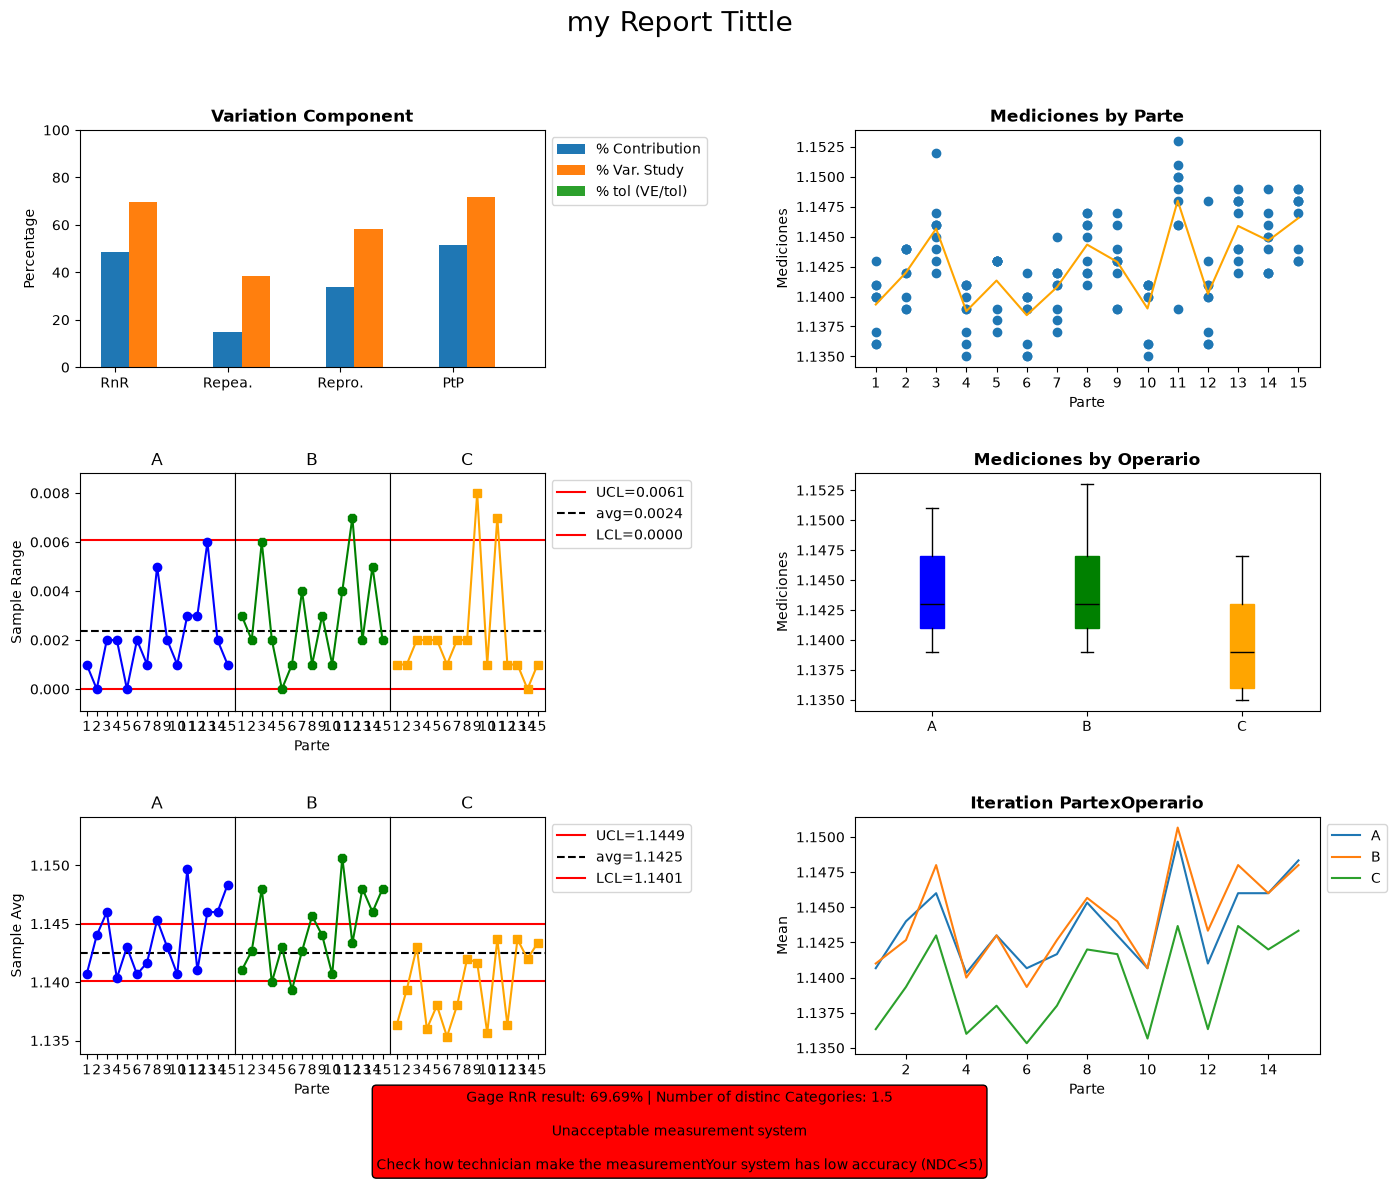

In [173]:
call=RnRModel.RnR_Report("my Report Tittle")
plt.show()

## Ejemplo 5

In [174]:
n_operarios=3
n_replicas = 3
n_piezas = 15
Operario = [str('OPE_')+str(item+1) for _ in range(n_piezas) for item in range(n_operarios) for _ in range(n_replicas)  ]
print(Operario)

['OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 'OPE_2', 'OPE_2', 'OPE_2', 'OPE_3', 'OPE_3', 'OPE_3', 'OPE_1', 'OPE_1', 'OPE_1', 

In [175]:
len(Operario)

135

In [176]:
numero_operario = [(item+1) for _ in range(n_piezas) for item in range(n_operarios) for _ in range(n_replicas)  ]
print(numero_operario)

[1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3]


In [177]:
Parte = [str('Parte_')+str(item+1) for item in range(n_piezas) for _ in range(n_operarios) for _ in range(n_replicas)  ]
print(Parte)

['Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_1', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_2', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_3', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_4', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_5', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_6', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_7', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_8', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_9', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 'Parte_10', 

In [178]:
list_operario = pd.Series( numero_operario)
list_operario

0      1
1      1
2      1
3      2
4      2
      ..
130    2
131    2
132    3
133    3
134    3
Length: 135, dtype: int64

In [179]:
type(list_operario)

pandas.core.series.Series

In [180]:
# Initialize the modern NumPy random generator
rng = np.random.default_rng(seed=42)  # Seed ensures reproducible results

# 1. Random floats 

aleatorio_v = [rng.normal(loc=0.2*(item+1), scale=0.2*(item+1), size=1)[0] for _ in range(n_piezas) for item in range(n_operarios) for _ in range(n_replicas)  ]


In [181]:
Mediciones = 0.5+ list_operario*0.1 +aleatorio_v
Mediciones

0      0.860943
1      0.592003
2      0.950090
3      1.476226
4      0.319586
         ...   
130    0.944076
131    0.549326
132    1.781091
133    1.266666
134    0.517516
Length: 135, dtype: float64

In [182]:
(type(Operario), type(Parte), type(Mediciones))

(list, list, pandas.core.series.Series)

In [183]:
df = pd.DataFrame({'Operario':Operario, 'Parte':Parte, 'Mediciones':Mediciones})

In [184]:
df

,Operario,Parte,Mediciones
0,OPE_1,Parte_1,0.860943
1,OPE_1,Parte_1,0.592003
2,OPE_1,Parte_1,0.950090
3,OPE_2,Parte_1,1.476226
4,OPE_2,Parte_1,0.319586
...,...,...,...
130,OPE_2,Parte_15,0.944076
131,OPE_2,Parte_15,0.549326
132,OPE_3,Parte_15,1.781091
133,OPE_3,Parte_15,1.266666


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Operario    135 non-null    object 
 1   Parte       135 non-null    object 
 2   Mediciones  135 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.3+ KB


In [186]:
#Build up the model
dict_key={
        '1':'Operario',
        '2':'Parte',
        '3':'Mediciones'
        }
RnRModel=RnR.RnRNumeric(
    mydf_Raw=df,
    mydict_key=dict_key,
    mydbl_tol=2
    )
#Solve it
RnRModel.RnRSolve()
#Check the calculation
print(RnRModel.getLog())

Model is created
== DATASET EVALUATION ==
Operator: 3
Trials: 3
Piezes: 15
== CALCULATION ==
Total data: 135
Max. measured value: 2.2155
Min. measured value: 0.3196
Avg. measured value: 1.0583
Avg. Control limits
UCL: 1.6023
LCL: 0.5142
Avg. Range measured: 0.5318
Range Control limits
UCL: 1.3689
LCL: 0.0000
Sum of deviation by operator: 0.121911
Total Operator Sum of deviation: 5.486007
Sum of deviation by part: 0.203250
Total Part Sum of deviation: 1.829251
Total squared deviation: 20.819006
Equipment squared deviation: 9.866535
Iteration sum of squared: 3.637214



In [187]:
df_Result=RnRModel.RnRAnova()
#Checking Anova table
print(df_Result)
#accesing one individual value
print(f"Degree of freedom for part: {df_Result['DF'].loc['Part']}")

                        DF         SS        MS          F         P
Source of variability                                               
Technician               2   5.486007  2.743003  21.116186  0.000003
Part                    14   1.829251  0.130661   1.005852  0.474383
TechxPart (iteration)   28   3.637214  0.129901   1.184919  0.269764
Repeatability with      90   9.866535  0.109628        NaN       NaN
Repeatability without  118  13.503749  0.114439        NaN  0.269764
Total                  134  20.819006       NaN        NaN       NaN
Degree of freedom for part: 14


In [188]:
df_Result=RnRModel.RnR_varTable()
#Checking var. table
print(df_Result)
#accesing one individual value
print('\nRnR RESULT:\n-------------------')

dbl_RnR=df_Result['% Contribution'].loc['Total Gage R&R']
print(f"Total Gage R&R: {dbl_RnR:.3f}")
if dbl_RnR<1:
    print('<1% --> Acceptable measurement system')
elif dbl_RnR>=1 and dbl_RnR<=9:
    print(
        '1-9%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>9% --> Unacceptable measurement system, it must be improved'
        )

                           Variance  % Contribution
Source                                             
Total Gage R&R             0.172851       98.967976
Eq.Var. (Repeatability)    0.114439       65.523168
Op.Var. (Reproducibility)  0.058413       33.444808
Technician                 0.058413       33.444808
Technician x Part iter.    0.000000        0.000000
Part to Part               0.001802        1.032024
Total variation            0.174654      100.000000

RnR RESULT:
-------------------
Total Gage R&R: 98.968
>9% --> Unacceptable measurement system, it must be improved


In [189]:
df_Result=RnRModel.RnR_SDTable()
#Checking sd table
print(df_Result)
#accesing one individual value
print('\nAutomotive Industry Action Group (AIAG) measurement system assessment:\n-------------------')

dbl_RnR=df_Result['% tol (VE/tol)'].loc['Total Gage R&R']
print(f"% tol (VE/tol): {dbl_RnR:.3f}")
if dbl_RnR<10:
    print('<10% --> Acceptable measurement system')
elif dbl_RnR>=10 and dbl_RnR<=30:
    print(
        '10-30%--> It may be acceptable depending on application and cost'
        )
else:
    print(
        '>30% --> Unacceptable measurement system, it must be improved'
        )

                           StdDev (SD)  StudyVar (6*SD)  % Study Var  \
Source                                                                 
Total Gage R&R                0.415754         2.494522    99.482650   
Eq.Var. (Repeatability)       0.338288         2.029726    80.946382   
Op.Var. (Reproducibility)     0.241687         1.450121    57.831486   
Technician                    0.241687         1.450121    57.831486   
Technician x Part iter.       0.000000         0.000000     0.000000   
Part to Part                  0.042455         0.254733    10.158859   
Total variation               0.417916         2.507494   100.000000   

                           % tol (VE/tol)  
Source                                     
Total Gage R&R                 124.726097  
Eq.Var. (Repeatability)        101.486303  
Op.Var. (Reproducibility)       72.506066  
Technician                      72.506066  
Technician x Part iter.          0.000000  
Part to Part                    12.736641  

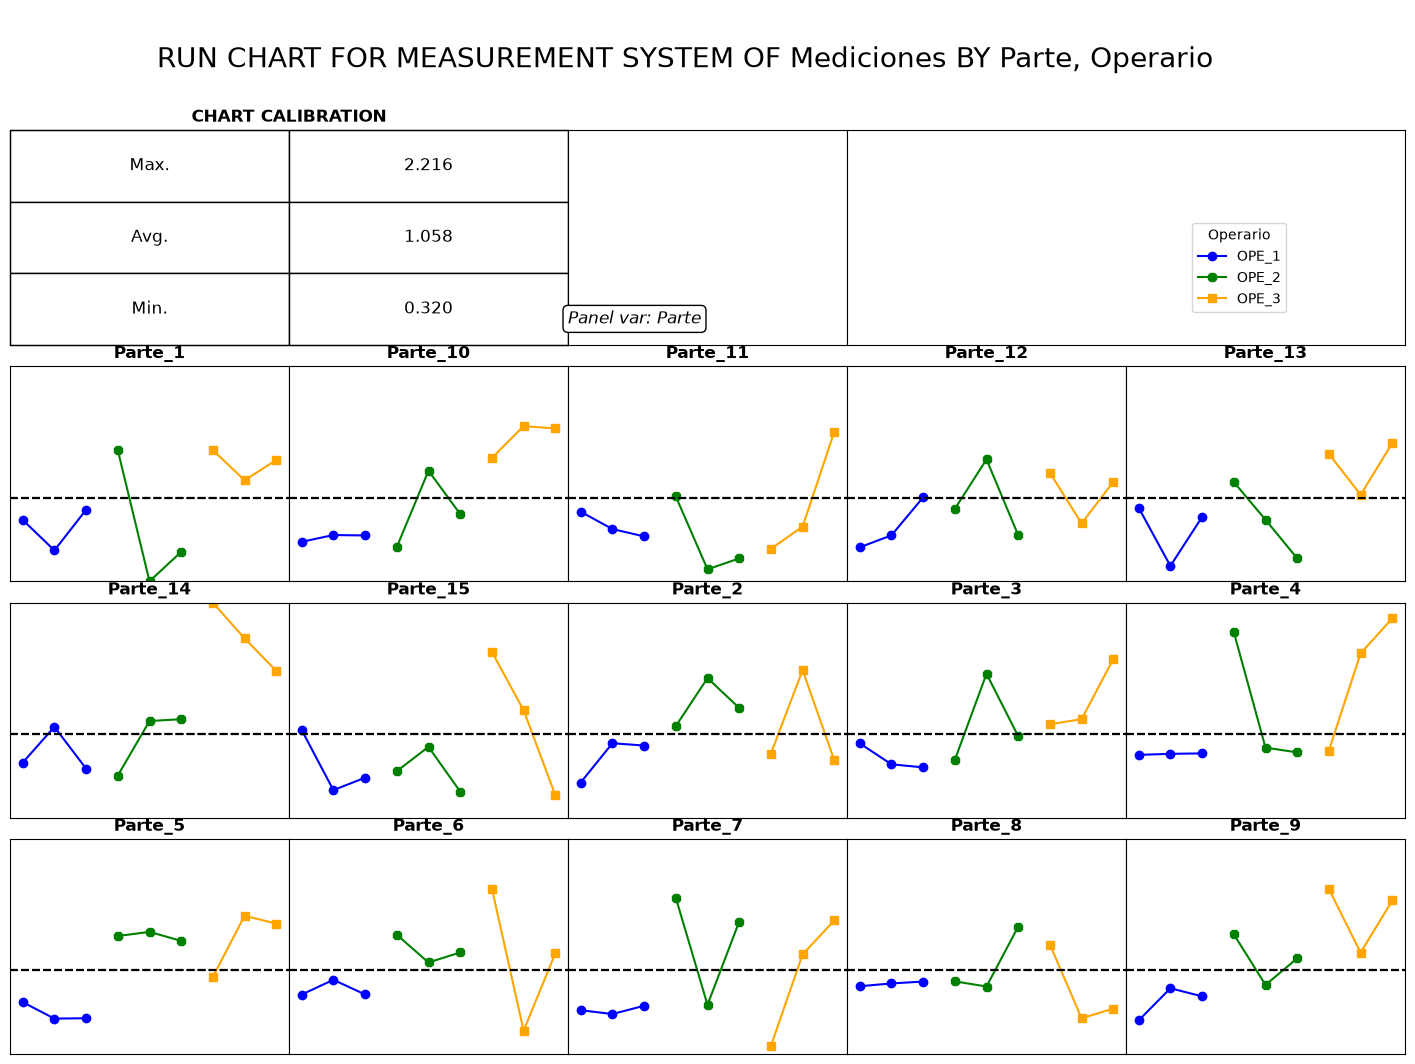

In [190]:
call=RnRModel.RnR_RunChart()
plt.show()

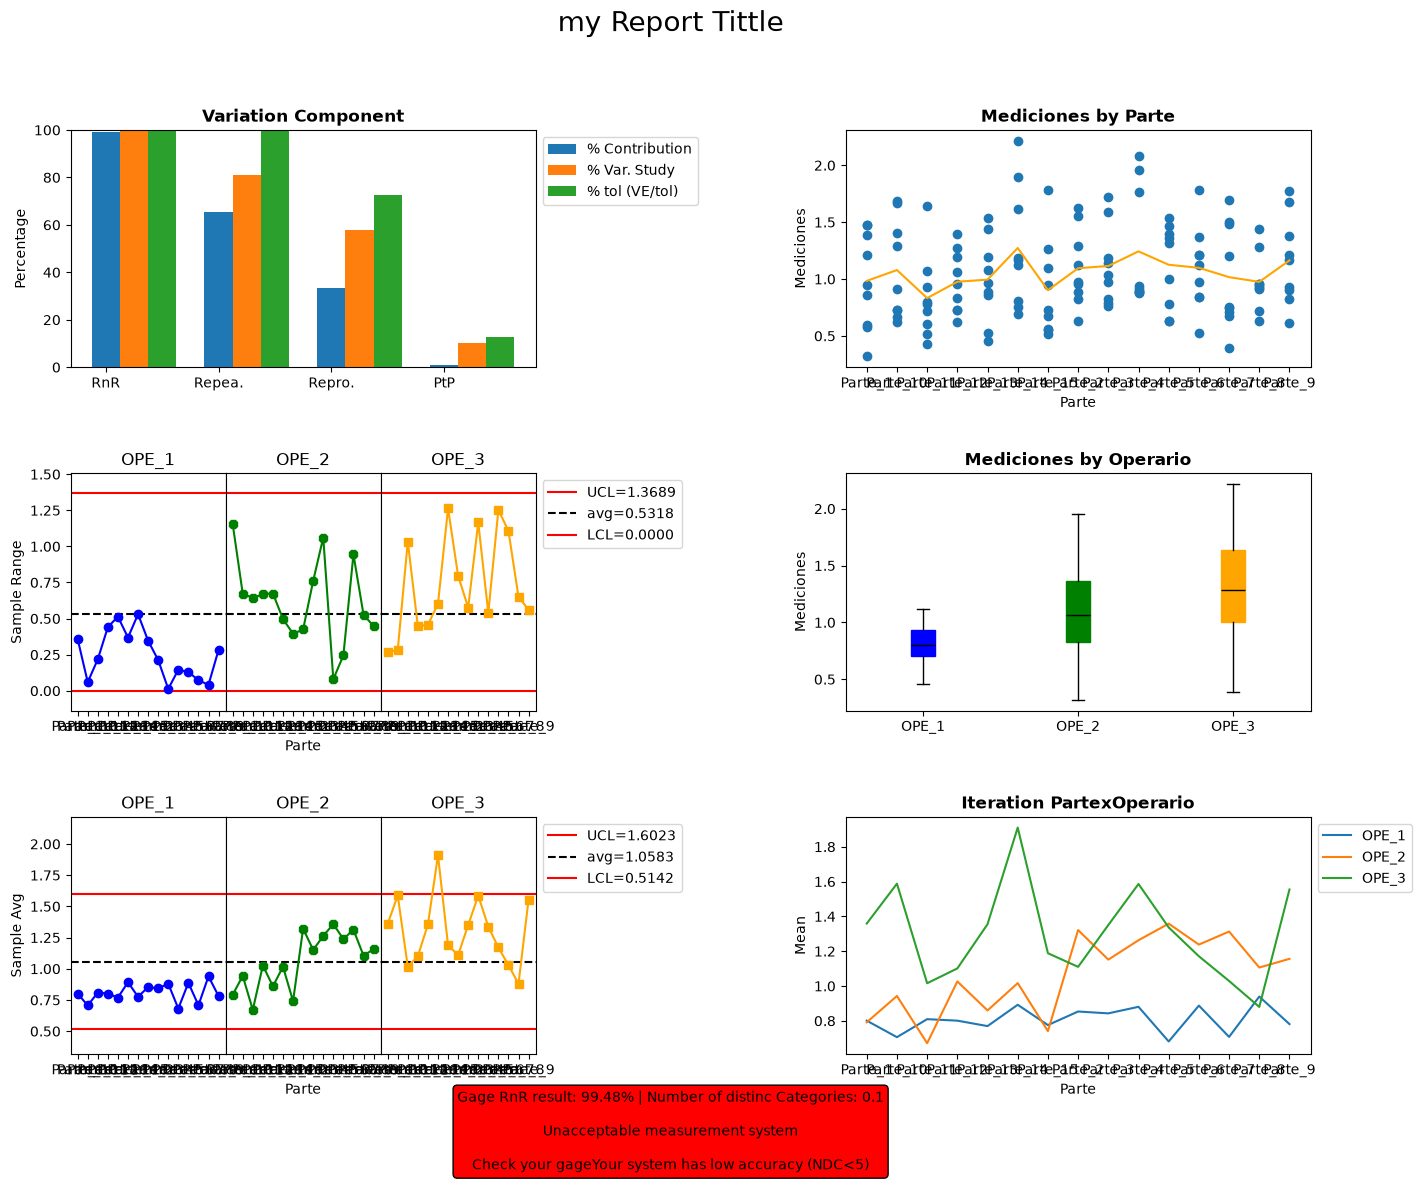

In [191]:
call=RnRModel.RnR_Report("my Report Tittle")
plt.show()